Menstrual_Cycle_ML_Project

In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif

# ML Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [3]:
# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Imbalanced data
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully!")

All libraries imported successfully!


In [6]:
# ============================================
# STEP 2: LOAD RAW DATASET
# ============================================

file_path = "/content/merged_menstrual_cycle_raw_dataset.csv"

df = pd.read_excel("/content/merged_menstrual_cycle_raw_data.xlsx")

print("Raw dataset loaded successfully!")

Raw dataset loaded successfully!


In [7]:
# Display first 10 rows

df.head(10)

,SourceDataset,ClientID,CycleNumber,Group,CycleWithPeakorNot,ReproductiveCategory,LengthofCycle,MeanCycleLength,EstimatedDayofOvulation,LengthofLutealPhase,...,sleep_hours_cycle,energy_level,concentration_score,work_hours_lost,estrogen_pgml,progesterone_ngml,ovulation_result,overall_health_score,log_consistency_score,prepared_before_period
0,FedCycleData071012_raw,nfp8122,1.0,0.0,1.0,0.0,29.0,27.33,17,12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,FedCycleData071012_raw,nfp8122,2.0,0.0,1.0,0.0,27.0,,15,12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,FedCycleData071012_raw,nfp8122,3.0,0.0,1.0,0.0,29.0,,15,14,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,FedCycleData071012_raw,nfp8122,4.0,0.0,1.0,0.0,27.0,,15,12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,FedCycleData071012_raw,nfp8122,5.0,0.0,1.0,0.0,28.0,,16,12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,FedCycleData071012_raw,nfp8122,6.0,0.0,1.0,0.0,26.0,,15,11,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,FedCycleData071012_raw,nfp8122,7.0,0.0,1.0,0.0,29.0,,16,13,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,FedCycleData071012_raw,nfp8122,8.0,0.0,1.0,2.0,24.0,,14,10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,FedCycleData071012_raw,nfp8122,9.0,0.0,1.0,0.0,28.0,,16,12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,FedCycleData071012_raw,nfp8122,10.0,0.0,1.0,0.0,28.0,,17,11,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
# Display last 10 rows

df.tail(10)

,SourceDataset,ClientID,CycleNumber,Group,CycleWithPeakorNot,ReproductiveCategory,LengthofCycle,MeanCycleLength,EstimatedDayofOvulation,LengthofLutealPhase,...,sleep_hours_cycle,energy_level,concentration_score,work_hours_lost,estrogen_pgml,progesterone_ngml,ovulation_result,overall_health_score,log_consistency_score,prepared_before_period
20526,Period_Log,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.7,7.0,6.0,4.7,84.2,2.45,Negative,7.9,0.946,0.0
20527,Period_Log,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,5.3,6.0,6.0,2.6,72.9,3.67,Negative,9.0,0.946,1.0
20528,Period_Log,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.5,4.0,4.0,5.1,52.6,7.71,Negative,6.4,0.946,1.0
20529,Period_Log,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.5,8.0,7.0,5.3,73.2,8.65,Negative,7.8,0.946,1.0
20530,Period_Log,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.5,5.0,6.0,5.9,92.0,1.77,Negative,6.9,0.946,1.0
20531,Period_Log,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,5.2,6.0,7.0,5.3,77.5,5.31,Negative,8.1,0.946,1.0
20532,Period_Log,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,5.6,8.0,6.0,3.0,65.5,0.74,Positive,7.6,0.946,1.0
20533,Period_Log,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.5,6.0,7.0,4.6,51.9,1.26,Negative,7.6,0.946,0.0
20534,Period_Log,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.9,6.0,8.0,3.0,85.3,8.99,Positive,8.8,0.946,1.0
20535,Period_Log,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.6,7.0,9.0,3.7,109.1,2.17,Negative,8.5,0.946,1.0


In [9]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 20536
Number of columns: 112


In [10]:
print("Columns in the dataset:")
for i, col in enumerate(df.columns):
    print(i, ":", col)

Columns in the dataset:
0 : SourceDataset
1 : ClientID
2 : CycleNumber
3 : Group
4 : CycleWithPeakorNot
5 : ReproductiveCategory
6 : LengthofCycle
7 : MeanCycleLength
8 : EstimatedDayofOvulation
9 : LengthofLutealPhase
10 : FirstDayofHigh
11 : TotalNumberofHighDays
12 : TotalHighPostPeak
13 : TotalNumberofPeakDays
14 : TotalDaysofFertility
15 : TotalFertilityFormula
16 : LengthofMenses
17 : MeanMensesLength
18 : MensesScoreDayOne
19 : MensesScoreDayTwo
20 : MensesScoreDayThree
21 : MensesScoreDayFour
22 : MensesScoreDayFive
23 : MensesScoreDaySix
24 : MensesScoreDaySeven
25 : MensesScoreDayEight
26 : MensesScoreDayNine
27 : MensesScoreDayTen
28 : MensesScoreDay11
29 : MensesScoreDay12
30 : MensesScoreDay13
31 : MensesScoreDay14
32 : MensesScoreDay15
33 : TotalMensesScore
34 : MeanBleedingIntensity
35 : NumberofDaysofIntercourse
36 : IntercourseInFertileWindow
37 : UnusualBleeding
38 : PhasesBleeding
39 : IntercourseDuringUnusBleed
40 : Age
41 : AgeM
42 : Maristatus
43 : MaristatusM
44 

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20536 entries, 0 to 20535
Columns: 112 entries, SourceDataset to prepared_before_period
dtypes: float64(25), object(87)
memory usage: 17.5+ MB


In [12]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
SourceDataset,20536,3,Period_Log,17976,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ClientID,1665,159,nfp8122,45,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CycleNumber,1665.0,NaN,NaN,NaN,8.040841,6.593686,1.0,3.0,7.0,11.0,45.0
Group,1665.0,NaN,NaN,NaN,0.382583,0.486164,0.0,0.0,0.0,1.0,1.0
CycleWithPeakorNot,1665.0,NaN,NaN,NaN,0.912312,0.282925,0.0,1.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
progesterone_ngml,17976.0,NaN,NaN,NaN,5.336521,3.791151,0.1,2.23,3.83,8.37,20.25
ovulation_result,17976,2,Positive,9730,NaN,NaN,NaN,NaN,NaN,NaN,NaN
overall_health_score,17976.0,NaN,NaN,NaN,8.548665,1.106405,4.4,7.8,8.6,9.5,10.0
log_consistency_score,17976.0,NaN,NaN,NaN,0.935288,0.020129,0.86,0.921,0.936,0.95,0.985


In [13]:
missing_values = df.isnull().sum()

print("Missing values:")
print(missing_values[missing_values > 0])

Missing values:
ClientID                  18871
CycleNumber               18871
Group                     18871
CycleWithPeakorNot        18871
ReproductiveCategory      18871
                          ...  
progesterone_ngml          2560
ovulation_result           2560
overall_health_score       2560
log_consistency_score      2560
prepared_before_period     2560
Length: 111, dtype: int64


In [14]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 12


In [15]:
# ============================================
# STEP 4: CLEAN COLUMN NAMES
# ============================================

df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ", "_")
    .str.replace(r"[^\w]", "", regex=True)
)

print("Cleaned column names:")
print(df.columns.tolist())

Cleaned column names:
['SourceDataset', 'ClientID', 'CycleNumber', 'Group', 'CycleWithPeakorNot', 'ReproductiveCategory', 'LengthofCycle', 'MeanCycleLength', 'EstimatedDayofOvulation', 'LengthofLutealPhase', 'FirstDayofHigh', 'TotalNumberofHighDays', 'TotalHighPostPeak', 'TotalNumberofPeakDays', 'TotalDaysofFertility', 'TotalFertilityFormula', 'LengthofMenses', 'MeanMensesLength', 'MensesScoreDayOne', 'MensesScoreDayTwo', 'MensesScoreDayThree', 'MensesScoreDayFour', 'MensesScoreDayFive', 'MensesScoreDaySix', 'MensesScoreDaySeven', 'MensesScoreDayEight', 'MensesScoreDayNine', 'MensesScoreDayTen', 'MensesScoreDay11', 'MensesScoreDay12', 'MensesScoreDay13', 'MensesScoreDay14', 'MensesScoreDay15', 'TotalMensesScore', 'MeanBleedingIntensity', 'NumberofDaysofIntercourse', 'IntercourseInFertileWindow', 'UnusualBleeding', 'PhasesBleeding', 'IntercourseDuringUnusBleed', 'Age', 'AgeM', 'Maristatus', 'MaristatusM', 'Yearsmarried', 'Wedding', 'Religion', 'ReligionM', 'Ethnicity', 'EthnicityM', 'Sc

In [16]:
# ============================================
# REMOVE DUPLICATES
# ============================================

before = len(df)

df = df.drop_duplicates().reset_index(drop=True)

after = len(df)

print("Rows before removing duplicates:", before)
print("Rows after removing duplicates:", after)
print("Duplicates removed:", before - after)

Rows before removing duplicates: 20536
Rows after removing duplicates: 20524
Duplicates removed: 12


In [17]:
# ============================================
# CHECK DATA TYPES
# ============================================

print(df.dtypes)

SourceDataset              object
ClientID                   object
CycleNumber               float64
Group                     float64
CycleWithPeakorNot        float64
                           ...   
progesterone_ngml         float64
ovulation_result           object
overall_health_score      float64
log_consistency_score     float64
prepared_before_period    float64
Length: 112, dtype: object


In [18]:
# ============================================
# MISSING VALUE ANALYSIS
# ============================================

missing = df.isnull().sum()

missing_percentage = (
    df.isnull().mean() * 100
).round(2)

missing_table = pd.DataFrame({
    "Missing_Count": missing,
    "Missing_Percentage": missing_percentage
})

missing_table = missing_table[
    missing_table["Missing_Count"] > 0
].sort_values(
    "Missing_Count",
    ascending=False
)

missing_table

,Missing_Count,Missing_Percentage
Next_Cycle_Start_Date,19629,95.64
Exercise_Frequency,19629,95.64
Sleep_Hours,19629,95.64
Cycle_Start_Date,19629,95.64
Diet,19629,95.64
...,...,...
progesterone_ngml,2548,12.41
ovulation_result,2548,12.41
overall_health_score,2548,12.41
log_consistency_score,2548,12.41


In [19]:
# ============================================
# IDENTIFY NUMERIC AND CATEGORICAL COLUMNS
# ============================================

numeric_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

categorical_columns = df.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numeric columns:")
print(numeric_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numeric columns:
['CycleNumber', 'Group', 'CycleWithPeakorNot', 'ReproductiveCategory', 'LengthofCycle', 'User_ID', 'Stress_Level', 'Sleep_Hours', 'Cycle_Length', 'Period_Length', 'cycle_number', 'cycle_length_days', 'prev_cycle_length', 'pain_level', 'mood_score', 'stress_score_cycle', 'sleep_hours_cycle', 'energy_level', 'concentration_score', 'work_hours_lost', 'estrogen_pgml', 'progesterone_ngml', 'overall_health_score', 'log_consistency_score', 'prepared_before_period']

Categorical columns:
['SourceDataset', 'ClientID', 'MeanCycleLength', 'EstimatedDayofOvulation', 'LengthofLutealPhase', 'FirstDayofHigh', 'TotalNumberofHighDays', 'TotalHighPostPeak', 'TotalNumberofPeakDays', 'TotalDaysofFertility', 'TotalFertilityFormula', 'LengthofMenses', 'MeanMensesLength', 'MensesScoreDayOne', 'MensesScoreDayTwo', 'MensesScoreDayThree', 'MensesScoreDayFour', 'MensesScoreDayFive', 'MensesScoreDaySix', 'MensesScoreDaySeven', 'MensesScoreDayEight', 'MensesScoreDayNine', 'MensesScoreDayTen', 'Men

In [20]:
# ============================================
# HANDLE MISSING VALUES
# ============================================

# Numeric columns → median
for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

# Categorical columns → mode
for col in categorical_columns:
    if df[col].isnull().sum() > 0:
        mode_value = df[col].mode()

        if len(mode_value) > 0:
            df[col] = df[col].fillna(mode_value.iloc[0])

print("Missing values handled.")

Missing values handled.


In [21]:
print("Total remaining missing values:",
      df.isnull().sum().sum())

Total remaining missing values: 0


In [22]:
# ============================================
# DATA VALIDATION
# ============================================

print("Negative values in numerical columns:")

for col in numeric_columns:
    negative_count = (df[col] < 0).sum()

    if negative_count > 0:
        print(col, ":", negative_count)

Negative values in numerical columns:


In [23]:
df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
CycleNumber,20524.0,7.086387,1.896301,1.00,7.000,7.000,7.000,45.000
Group,20524.0,0.031037,0.173421,0.00,0.000,0.000,0.000,1.000
CycleWithPeakorNot,20524.0,0.993033,0.083182,0.00,1.000,1.000,1.000,1.000
ReproductiveCategory,20524.0,0.004483,0.137425,0.00,0.000,0.000,0.000,9.000
LengthofCycle,20524.0,29.025823,1.106965,18.00,29.000,29.000,29.000,54.000
User_ID,20524.0,50.973738,6.078443,1.00,51.000,51.000,51.000,100.000
Stress_Level,20524.0,3.003459,0.300461,1.00,3.000,3.000,3.000,5.000
Sleep_Hours,20524.0,7.095147,0.254831,5.10,7.100,7.100,7.100,9.000
Cycle_Length,20524.0,37.016274,1.559903,25.00,37.000,37.000,37.000,50.000
Period_Length,20524.0,5.000780,0.289327,3.00,5.000,5.000,5.000,7.000


In [24]:
# ============================================
# OUTLIER DETECTION USING IQR
# ============================================

outlier_summary = []

for col in numeric_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = (
        (df[col] < lower) |
        (df[col] > upper)
    ).sum()

    outlier_summary.append([
        col,
        count,
        round((count / len(df)) * 100, 2)
    ])

outlier_table = pd.DataFrame(
    outlier_summary,
    columns=[
        "Feature",
        "Outlier_Count",
        "Outlier_Percentage"
    ]
)

outlier_table.sort_values(
    "Outlier_Count",
    ascending=False
)

,Feature,Outlier_Count,Outlier_Percentage
18,concentration_score,3027,14.75
0,CycleNumber,1547,7.54
4,LengthofCycle,1466,7.14
12,prev_cycle_length,938,4.57
5,User_ID,885,4.31
7,Sleep_Hours,878,4.28
8,Cycle_Length,868,4.23
6,Stress_Level,752,3.66
9,Period_Length,701,3.42
1,Group,637,3.10


In [25]:
print("Available columns:")
print(df.columns.tolist())

Available columns:
['SourceDataset', 'ClientID', 'CycleNumber', 'Group', 'CycleWithPeakorNot', 'ReproductiveCategory', 'LengthofCycle', 'MeanCycleLength', 'EstimatedDayofOvulation', 'LengthofLutealPhase', 'FirstDayofHigh', 'TotalNumberofHighDays', 'TotalHighPostPeak', 'TotalNumberofPeakDays', 'TotalDaysofFertility', 'TotalFertilityFormula', 'LengthofMenses', 'MeanMensesLength', 'MensesScoreDayOne', 'MensesScoreDayTwo', 'MensesScoreDayThree', 'MensesScoreDayFour', 'MensesScoreDayFive', 'MensesScoreDaySix', 'MensesScoreDaySeven', 'MensesScoreDayEight', 'MensesScoreDayNine', 'MensesScoreDayTen', 'MensesScoreDay11', 'MensesScoreDay12', 'MensesScoreDay13', 'MensesScoreDay14', 'MensesScoreDay15', 'TotalMensesScore', 'MeanBleedingIntensity', 'NumberofDaysofIntercourse', 'IntercourseInFertileWindow', 'UnusualBleeding', 'PhasesBleeding', 'IntercourseDuringUnusBleed', 'Age', 'AgeM', 'Maristatus', 'MaristatusM', 'Yearsmarried', 'Wedding', 'Religion', 'ReligionM', 'Ethnicity', 'EthnicityM', 'Schoo

In [26]:
[col for col in df.columns
 if any(word in col.lower()
        for word in [
            "cycle",
            "period",
            "menstrual",
            "ovulation",
            "luteal"
        ])]

['CycleNumber',
 'CycleWithPeakorNot',
 'LengthofCycle',
 'MeanCycleLength',
 'EstimatedDayofOvulation',
 'LengthofLutealPhase',
 'Cycle_Start_Date',
 'Cycle_Length',
 'Period_Length',
 'Next_Cycle_Start_Date',
 'cycle_number',
 'cycle_length_days',
 'prev_cycle_length',
 'cycle_phase',
 'stress_score_cycle',
 'sleep_hours_cycle',
 'ovulation_result',
 'prepared_before_period']

In [27]:
[col for col in df.columns
 if "cycle" in col.lower() and
 "length" in col.lower()]

['LengthofCycle',
 'MeanCycleLength',
 'Cycle_Length',
 'cycle_length_days',
 'prev_cycle_length']

In [29]:
# ============================================
# CREATE TARGET
# ============================================

TARGET_SOURCE = "Cycle_Length"

df["Cycle_Type"] = np.where(
    df[TARGET_SOURCE].between(21, 35),
    "Regular",
    "Irregular"
)

print(df["Cycle_Type"].value_counts())

Cycle_Type
Irregular    20132
Regular        392
Name: count, dtype: int64


In [30]:
# ============================================
# ENCODE TARGET
# ============================================

df["Target"] = df["Cycle_Type"].map({
    "Irregular": 0,
    "Regular": 1
})

print(df[["Cycle_Type", "Target"]].head())

  Cycle_Type  Target
0  Irregular       0
1  Irregular       0
2  Irregular       0
3  Irregular       0
4  Irregular       0


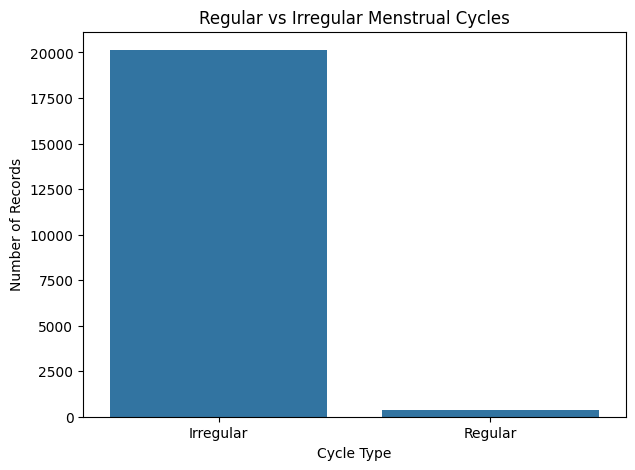

In [31]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Cycle_Type"
)

plt.title("Regular vs Irregular Menstrual Cycles")
plt.xlabel("Cycle Type")
plt.ylabel("Number of Records")

plt.show()

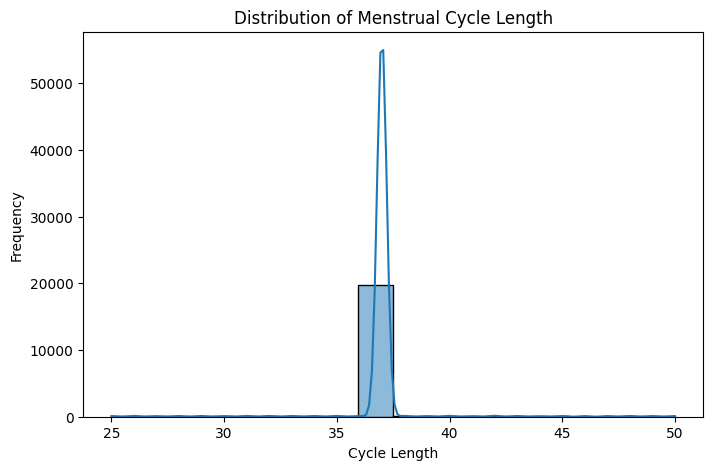

In [32]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x=TARGET_SOURCE,
    kde=True
)

plt.title("Distribution of Menstrual Cycle Length")
plt.xlabel("Cycle Length")
plt.ylabel("Frequency")

plt.show()

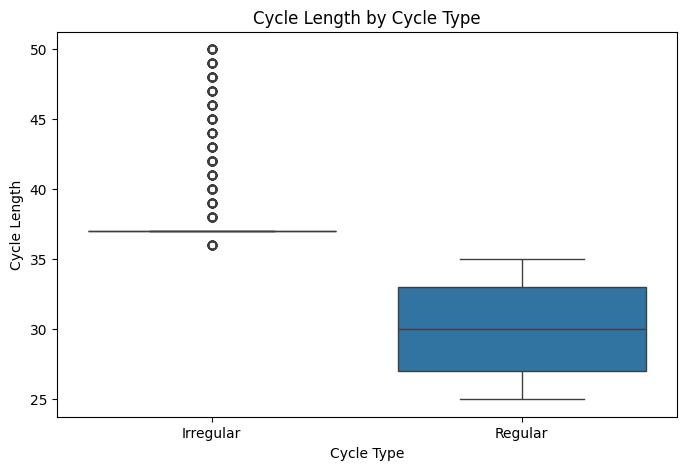

In [33]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Cycle_Type",
    y=TARGET_SOURCE
)

plt.title("Cycle Length by Cycle Type")
plt.xlabel("Cycle Type")
plt.ylabel("Cycle Length")

plt.show()

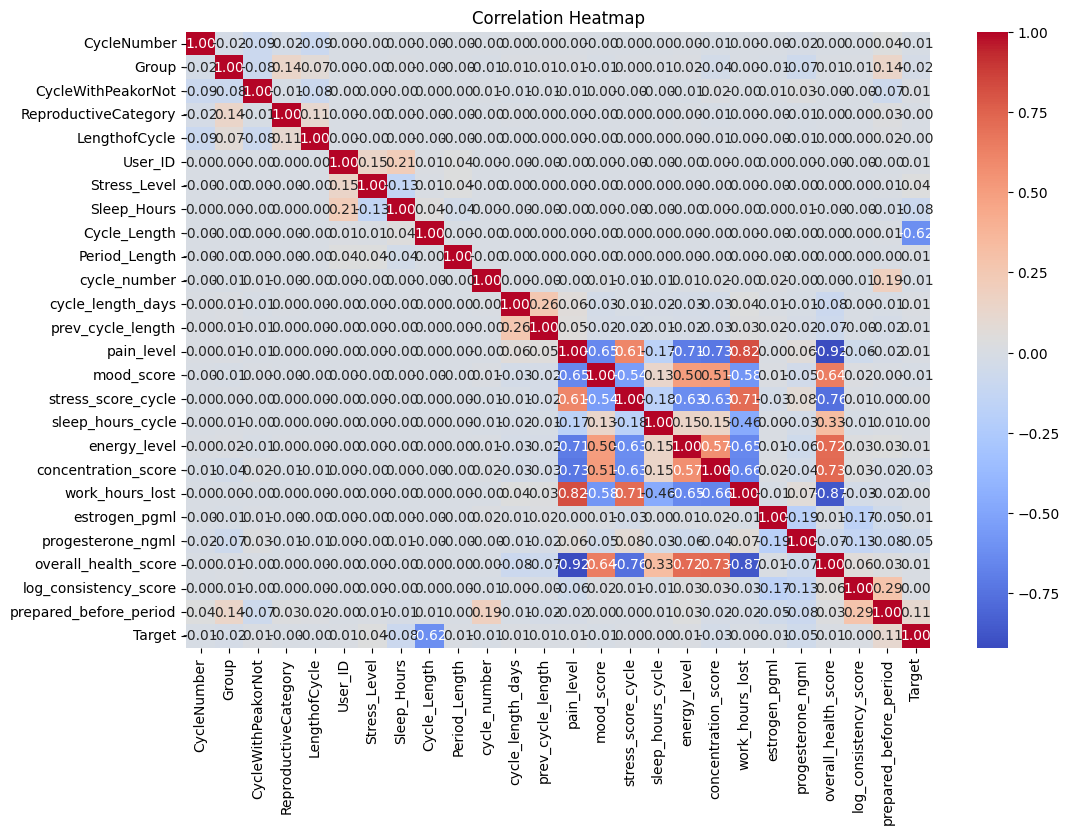

In [34]:
plt.figure(figsize=(12,8))

numeric_data = df.select_dtypes(
    include=np.number
)

correlation = numeric_data.corr()

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [36]:
# ============================================
# FEATURES AND TARGET
# ============================================

y = df["Target"]

X = df.drop(
    columns=[
        "Target",
        "Cycle_Type"
    ]
)

In [37]:
# Remove the variable used to create the target
# to prevent target leakage.

X = X.drop(
    columns=[TARGET_SOURCE],
    errors="ignore"
)

print("Features before preprocessing:")
print(X.columns.tolist())

Features before preprocessing:
['SourceDataset', 'ClientID', 'CycleNumber', 'Group', 'CycleWithPeakorNot', 'ReproductiveCategory', 'LengthofCycle', 'MeanCycleLength', 'EstimatedDayofOvulation', 'LengthofLutealPhase', 'FirstDayofHigh', 'TotalNumberofHighDays', 'TotalHighPostPeak', 'TotalNumberofPeakDays', 'TotalDaysofFertility', 'TotalFertilityFormula', 'LengthofMenses', 'MeanMensesLength', 'MensesScoreDayOne', 'MensesScoreDayTwo', 'MensesScoreDayThree', 'MensesScoreDayFour', 'MensesScoreDayFive', 'MensesScoreDaySix', 'MensesScoreDaySeven', 'MensesScoreDayEight', 'MensesScoreDayNine', 'MensesScoreDayTen', 'MensesScoreDay11', 'MensesScoreDay12', 'MensesScoreDay13', 'MensesScoreDay14', 'MensesScoreDay15', 'TotalMensesScore', 'MeanBleedingIntensity', 'NumberofDaysofIntercourse', 'IntercourseInFertileWindow', 'UnusualBleeding', 'PhasesBleeding', 'IntercourseDuringUnusBleed', 'Age', 'AgeM', 'Maristatus', 'MaristatusM', 'Yearsmarried', 'Wedding', 'Religion', 'ReligionM', 'Ethnicity', 'Ethnici

In [38]:
# ============================================
# CONVERT CATEGORICAL VARIABLES
# ============================================

X = pd.get_dummies(
    X,
    drop_first=True
)

print("Number of features:", X.shape[1])
print(X.head())

Number of features: 5617
   CycleNumber  Group  CycleWithPeakorNot  ReproductiveCategory  \
0          1.0    0.0                 1.0                   0.0   
1          2.0    0.0                 1.0                   0.0   
2          3.0    0.0                 1.0                   0.0   
3          4.0    0.0                 1.0                   0.0   
4          5.0    0.0                 1.0                   0.0   

   LengthofCycle  User_ID  Stress_Level  Sleep_Hours  Period_Length  \
0           29.0     51.0           3.0          7.1            5.0   
1           27.0     51.0           3.0          7.1            5.0   
2           29.0     51.0           3.0          7.1            5.0   
3           27.0     51.0           3.0          7.1            5.0   
4           28.0     51.0           3.0          7.1            5.0   

   cycle_number  ...  start_date_2025-03-05  start_date_2025-03-15  \
0           5.0  ...                  False                  False   
1    

In [39]:
X = X.apply(
    pd.to_numeric,
    errors="coerce"
)

print(X.dtypes.value_counts())

bool       5593
float64      24
Name: count, dtype: int64


In [40]:
# ============================================
# FINAL FEATURE IMPUTATION
# ============================================

imputer = SimpleImputer(
    strategy="median"
)

X_imputed = imputer.fit_transform(X)

X = pd.DataFrame(
    X_imputed,
    columns=X.columns,
    index=X.index
)

print("Missing values in X:",
      X.isnull().sum().sum())

Missing values in X: 0


In [46]:
# ============================================
# REMOVE CONSTANT FEATURES
# ============================================

constant_columns = []
for col_name, col_data in X.items():
    if col_data.nunique(dropna=True) <= 1:
        constant_columns.append(col_name)

print("Constant columns:", constant_columns)

X = X.drop(
    columns=constant_columns
)

print("Final number of features:",
      X.shape[1])

Constant columns: []
Final number of features: 5617


In [47]:
# ============================================
# TRAIN TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (16419, 5617)
Testing data: (4105, 5617)


In [48]:
# ============================================
# FEATURE SELECTION
# ============================================

k = min(10, X_train.shape[1])

selector = SelectKBest(
    score_func=f_classif,
    k=k
)

X_train_selected = selector.fit_transform(
    X_train,
    y_train
)

X_test_selected = selector.transform(
    X_test
)

selected_features = X_train.columns[
    selector.get_support()
]

print("Selected features:")
print(selected_features.tolist())

Selected features:
['SourceDataset_Period_Log', 'SourceDataset_menstrual_cycle_dataset_with_factors', 'Age_ ', 'BMI_ ', 'Exercise_Frequency_Low', 'Exercise_Frequency_Moderate', 'Diet_Low Carb', 'Diet_Vegetarian', 'user_id_U00002', 'start_date_2024-04-03']


In [49]:
feature_scores = pd.DataFrame({
    "Feature": X_train.columns,
    "Score": selector.scores_,
    "P_Value": selector.pvalues_
})

feature_scores = feature_scores.sort_values(
    "Score",
    ascending=False
)

feature_scores.head(10)

,Feature,Score,P_Value
25,SourceDataset_menstrual_cycle_dataset_with_fac...,12552.078986,0.0
1297,BMI_,9900.894834,0.0
741,Age_,9718.486681,0.0
1413,Diet_Vegetarian,7174.561268,0.0
1409,Exercise_Frequency_Low,2800.998790,0.0
24,SourceDataset_Period_Log,2625.778952,0.0
3206,user_id_U00002,2608.786231,0.0
5297,start_date_2024-04-03,2523.498411,0.0
1410,Exercise_Frequency_Moderate,2446.330826,0.0
1412,Diet_Low Carb,1595.306684,0.0


In [50]:
# ============================================
# FEATURE SCALING
# ============================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train_selected
)

X_test_scaled = scaler.transform(
    X_test_selected
)

print("Feature scaling completed.")

Feature scaling completed.


In [51]:
# ============================================
# CHECK CLASS BALANCE
# ============================================

print("Before SMOTE:")
print(y_train.value_counts())

print("\nClass percentages:")
print(
    y_train.value_counts(normalize=True) * 100
)

Before SMOTE:
Target
0    16105
1      314
Name: count, dtype: int64

Class percentages:
Target
0    98.087581
1     1.912419
Name: proportion, dtype: float64


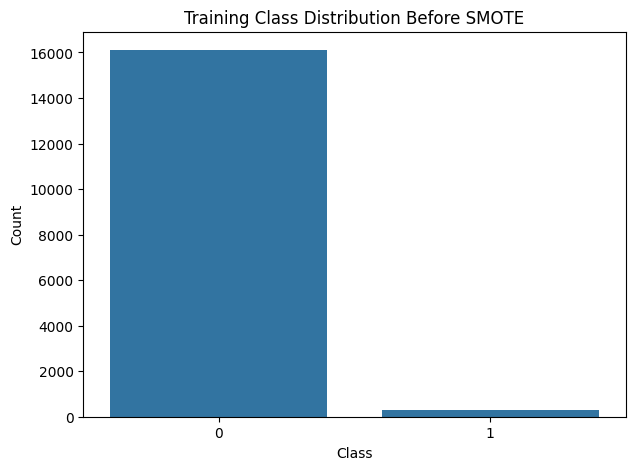

In [52]:
plt.figure(figsize=(7,5))

sns.countplot(
    x=y_train
)

plt.title("Training Class Distribution Before SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

In [53]:
# ============================================
# SMOTE
# ============================================

smote = SMOTE(
    random_state=42
)

X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("After SMOTE:")
print(y_train_balanced.value_counts())

After SMOTE:
Target
0    16105
1    16105
Name: count, dtype: int64


In [54]:
# ============================================
# MODEL 1: LOGISTIC REGRESSION
# ============================================

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_balanced,
    y_train_balanced
)

lr_prediction = logistic_model.predict(
    X_test_scaled
)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [55]:
# ============================================
# MODEL 2: RANDOM FOREST
# ============================================

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train_selected,
    y_train
)

rf_prediction = rf_model.predict(
    X_test_selected
)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [56]:
# ============================================
# HYPERPARAMETER TUNING
# LOGISTIC REGRESSION
# ============================================

lr_parameters = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"],
    "penalty": ["l2"]
}

lr_grid = GridSearchCV(
    estimator=LogisticRegression(
        max_iter=2000,
        random_state=42
    ),
    param_grid=lr_parameters,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

lr_grid.fit(
    X_train_balanced,
    y_train_balanced
)

print("Best Logistic Regression parameters:")
print(lr_grid.best_params_)

print("\nBest cross-validation F1 score:")
print(lr_grid.best_score_)

Best Logistic Regression parameters:
{'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}

Best cross-validation F1 score:
0.9879461695141337


In [57]:
best_lr = lr_grid.best_estimator_

lr_final_prediction = best_lr.predict(
    X_test_scaled
)

print("Final Logistic Regression prediction completed.")

Final Logistic Regression prediction completed.


In [58]:
# ============================================
# HYPERPARAMETER TUNING
# RANDOM FOREST
# ============================================

rf_parameters = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2"]
}

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42
    ),
    param_grid=rf_parameters,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

rf_grid.fit(
    X_train_selected,
    y_train
)

print("Best Random Forest parameters:")
print(rf_grid.best_params_)

print("\nBest cross-validation F1 score:")
print(rf_grid.best_score_)

Best Random Forest parameters:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Best cross-validation F1 score:
0.17440078201368522


In [59]:
best_rf = rf_grid.best_estimator_

rf_final_prediction = best_rf.predict(
    X_test_selected
)

print("Final Random Forest prediction completed.")

Final Random Forest prediction completed.


In [61]:
# ============================================
# MODEL EVALUATION FUNCTION
# ============================================

def evaluate_model(name, y_true, y_pred):

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    print("=" * 50)
    print(name)
    print("=" * 50)

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")

    print("\nClassification Report:")
    print(
        classification_report(
            y_true,
            y_pred,
            target_names=[
                "Irregular",
                "Regular"
            ],
            zero_division=0
        )
    )

    return [
        accuracy,
        precision,
        recall,
        f1
    ]

In [63]:
lr_scores = evaluate_model(
    "Logistic Regression",
    y_test,
    lr_final_prediction
)

Logistic Regression
Accuracy  : 0.9732
Precision : 0.4149
Recall    : 1.0000
F1 Score  : 0.5865

Classification Report:
              precision    recall  f1-score   support

   Irregular       1.00      0.97      0.99      4027
     Regular       0.41      1.00      0.59        78

    accuracy                           0.97      4105
   macro avg       0.71      0.99      0.79      4105
weighted avg       0.99      0.97      0.98      4105



In [64]:
rf_scores = evaluate_model(
    "Random Forest",
    y_test,
    rf_final_prediction
)

Random Forest
Accuracy  : 0.9820
Precision : 0.5714
Recall    : 0.2051
F1 Score  : 0.3019

Classification Report:
              precision    recall  f1-score   support

   Irregular       0.98      1.00      0.99      4027
     Regular       0.57      0.21      0.30        78

    accuracy                           0.98      4105
   macro avg       0.78      0.60      0.65      4105
weighted avg       0.98      0.98      0.98      4105



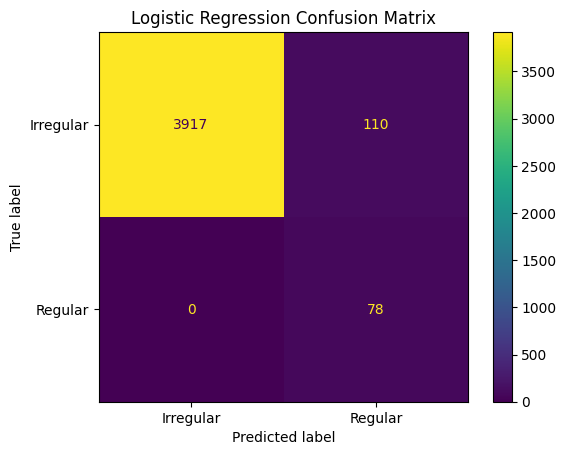

In [65]:
# ============================================
# CONFUSION MATRIX
# LOGISTIC REGRESSION
# ============================================

cm_lr = confusion_matrix(
    y_test,
    lr_final_prediction
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=[
        "Irregular",
        "Regular"
    ]
)

disp.plot()

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.show()

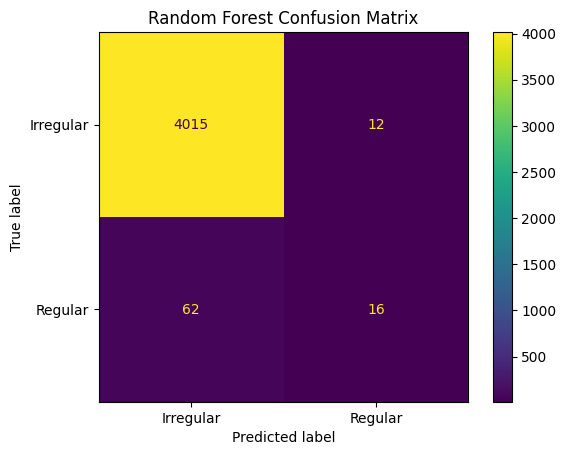

In [66]:
# ============================================
# CONFUSION MATRIX
# RANDOM FOREST
# ============================================

cm_rf = confusion_matrix(
    y_test,
    rf_final_prediction
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=[
        "Irregular",
        "Regular"
    ]
)

disp.plot()

plt.title(
    "Random Forest Confusion Matrix"
)

plt.show()

In [67]:
# ============================================
# MODEL COMPARISON
# ============================================

results = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],

    "Accuracy": [
        lr_scores[0],
        rf_scores[0]
    ],

    "Precision": [
        lr_scores[1],
        rf_scores[1]
    ],

    "Recall": [
        lr_scores[2],
        rf_scores[2]
    ],

    "F1 Score": [
        lr_scores[3],
        rf_scores[3]
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.973203,0.414894,1.000000,0.586466
1,Random Forest,0.981973,0.571429,0.205128,0.301887


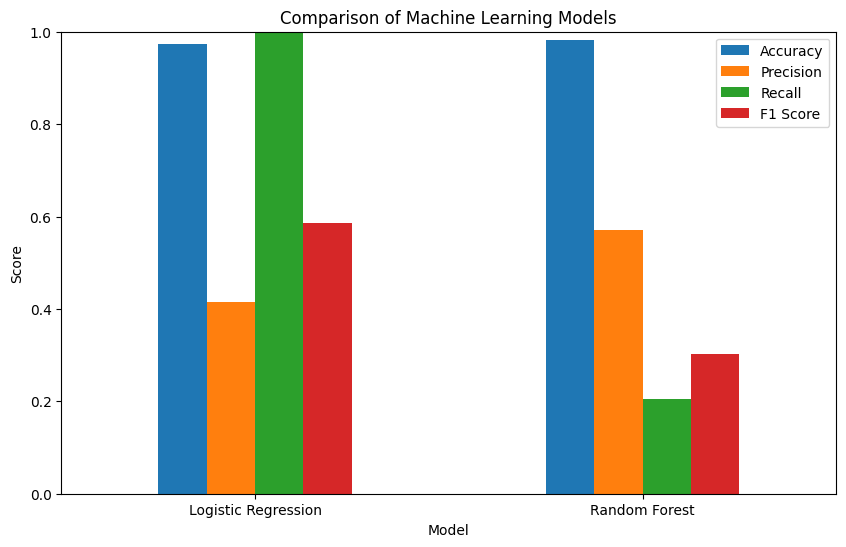

In [68]:
# ============================================
# MODEL PERFORMANCE COMPARISON
# ============================================

results_plot = results.set_index("Model")

results_plot.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Comparison of Machine Learning Models")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)

plt.show()

In [69]:
# ============================================
# FEATURE IMPORTANCE
# ============================================

feature_importance = pd.DataFrame({

    "Feature": selected_features,

    "Importance": best_rf.feature_importances_

})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance

,Feature,Importance
1,SourceDataset_menstrual_cycle_dataset_with_fac...,0.376464
3,BMI_,0.216159
2,Age_,0.180374
7,Diet_Vegetarian,0.132873
5,Exercise_Frequency_Moderate,0.031526
4,Exercise_Frequency_Low,0.029832
0,SourceDataset_Period_Log,0.015722
8,user_id_U00002,0.011024
6,Diet_Low Carb,0.006025
9,start_date_2024-04-03,0.000000


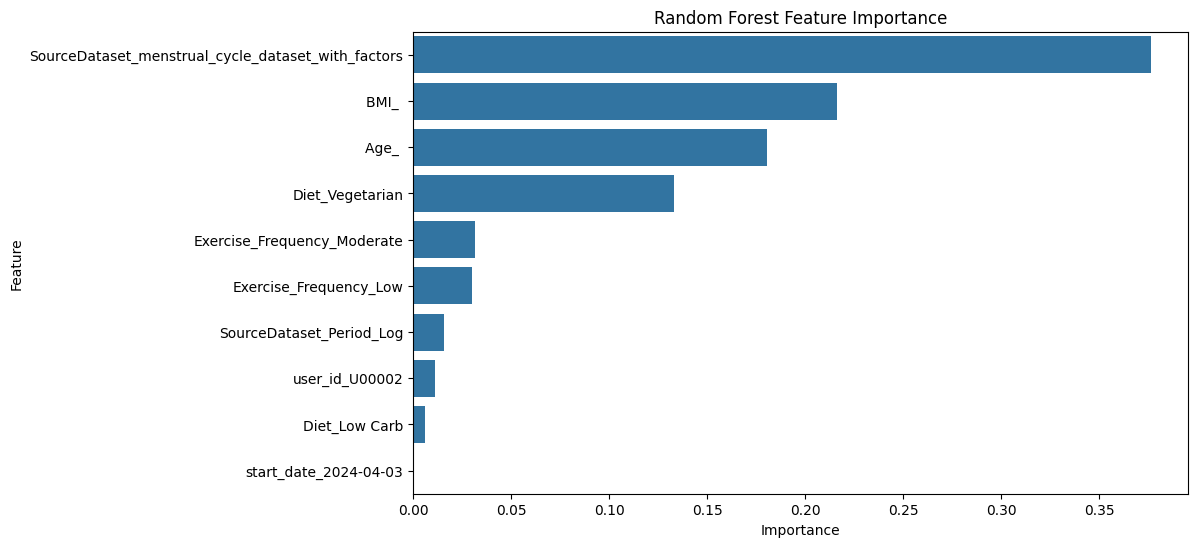

In [70]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title(
    "Random Forest Feature Importance"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

                 BEST MODEL
Best Model       : Logistic Regression
Best F1 Score    : 0.5865
Best Accuracy    : 0.9732


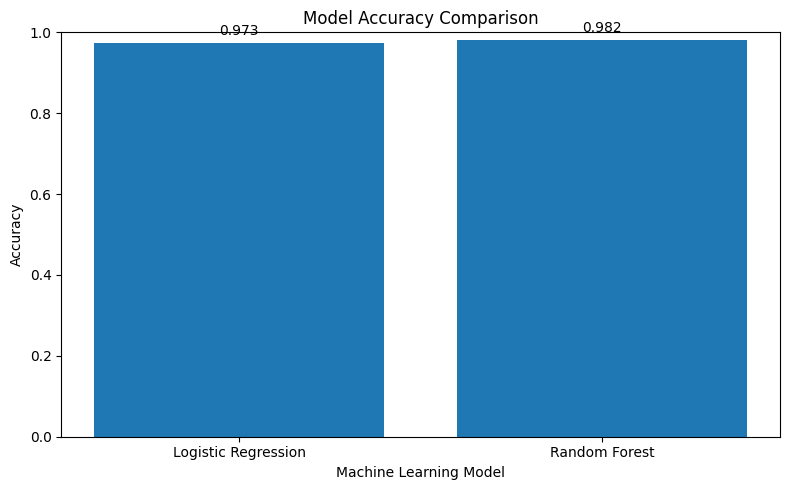

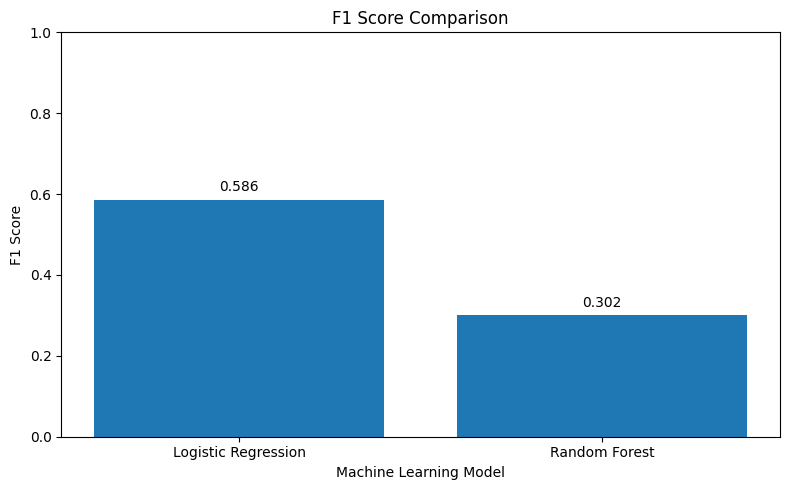

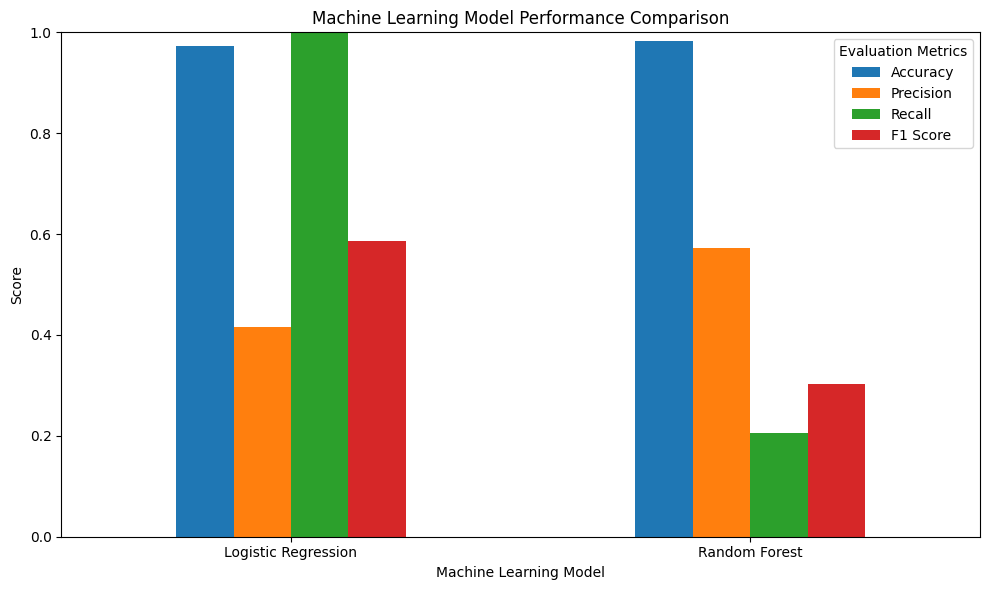

In [73]:
# ============================================================
# BEST MODEL + MODEL PERFORMANCE VISUALIZATION
# ============================================================

# Find the best model based on F1 Score
best_model_row = results.loc[
    results["F1 Score"].idxmax()
]

best_model_name = best_model_row["Model"]
best_f1 = best_model_row["F1 Score"]
best_accuracy = best_model_row["Accuracy"]

# Print best model information
print("==================================================")
print("                 BEST MODEL")
print("==================================================")

print("Best Model       :", best_model_name)
print("Best F1 Score    :", round(best_f1, 4))
print("Best Accuracy    :", round(best_accuracy, 4))

print("==================================================")


# ============================================================
# GRAPH 1: MODEL ACCURACY COMPARISON
# ============================================================

plt.figure(figsize=(8, 5))

bars = plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

# Show values on bars
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.02,
        f"{height:.3f}",
        ha="center"
    )

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# ============================================================
# GRAPH 2: F1 SCORE COMPARISON
# ============================================================

plt.figure(figsize=(8, 5))

bars = plt.bar(
    results["Model"],
    results["F1 Score"]
)

plt.title("F1 Score Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("F1 Score")
plt.ylim(0, 1)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.02,
        f"{height:.3f}",
        ha="center"
    )

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# ============================================================
# GRAPH 3: ALL MODEL PERFORMANCE METRICS
# ============================================================

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]

results.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Machine Learning Model Performance Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=0)
plt.legend(title="Evaluation Metrics")

plt.tight_layout()
plt.show()

In [74]:
# ============================================================
# FINAL PROJECT SUMMARY
# ============================================================

print("\n")
print("============================================================")
print("              MENSTRUAL CYCLE ML PROJECT")
print("============================================================")

# ------------------------------------------------------------
# DATASET INFORMATION
# ------------------------------------------------------------

print("\nDATASET INFORMATION")
print("------------------------------------------------------------")

print("Number of Rows    :", df.shape[0])
print("Number of Columns :", df.shape[1])

print("\nTarget Variable   : Target")

# ------------------------------------------------------------
# SELECTED FEATURES
# ------------------------------------------------------------

print("\nSELECTED FEATURES")
print("------------------------------------------------------------")

for i, feature in enumerate(selected_features, start=1):
    print(f"{i}. {feature}")

# ------------------------------------------------------------
# MODEL RESULTS
# ------------------------------------------------------------

print("\nMODEL PERFORMANCE")
print("------------------------------------------------------------")

print(
    results.to_string(index=False)
)

# ------------------------------------------------------------
# BEST MODEL
# ------------------------------------------------------------

print("\nBEST MODEL")
print("------------------------------------------------------------")

print("Model Name :", best_model_row["Model"])

print(
    "Accuracy   :",
    round(best_model_row["Accuracy"], 4)
)

print(
    "Precision  :",
    round(best_model_row["Precision"], 4)
)

print(
    "Recall     :",
    round(best_model_row["Recall"], 4)
)

print(
    "F1 Score   :",
    round(best_model_row["F1 Score"], 4)
)

# ------------------------------------------------------------
# FINAL CONCLUSION
# ------------------------------------------------------------

print("\nFINAL CONCLUSION")
print("------------------------------------------------------------")

print(
    f"The best performing model is {best_model_row['Model']} "
    f"based on the highest F1 Score."
)

print(
    f"The model achieved an accuracy of "
    f"{best_model_row['Accuracy']:.4f}."
)

print(
    "The selected features were used to train and evaluate "
    "two different machine learning algorithms."
)

print(
    "Hyperparameter tuning was performed using GridSearchCV "
    "with 5-fold cross-validation."
)

print(
    "Model performance was evaluated using Accuracy, "
    "Precision, Recall and F1 Score."
)

print("\n============================================================")
print("             PROJECT COMPLETED SUCCESSFULLY")
print("============================================================")



              MENSTRUAL CYCLE ML PROJECT

DATASET INFORMATION
------------------------------------------------------------
Number of Rows    : 20524
Number of Columns : 114

Target Variable   : Target

SELECTED FEATURES
------------------------------------------------------------
1. SourceDataset_Period_Log
2. SourceDataset_menstrual_cycle_dataset_with_factors
3. Age_ 
4. BMI_ 
5. Exercise_Frequency_Low
6. Exercise_Frequency_Moderate
7. Diet_Low Carb
8. Diet_Vegetarian
9. user_id_U00002
10. start_date_2024-04-03

MODEL PERFORMANCE
------------------------------------------------------------
              Model  Accuracy  Precision   Recall  F1 Score
Logistic Regression  0.973203   0.414894 1.000000  0.586466
      Random Forest  0.981973   0.571429 0.205128  0.301887

BEST MODEL
------------------------------------------------------------
Model Name : Logistic Regression
Accuracy   : 0.9732
Precision  : 0.4149
Recall     : 1.0
F1 Score   : 0.5865

FINAL CONCLUSION
-------------------